# Lab: Applications of Principal Component Analysis (PCA) 🧪

## Objectives 🎯
By the end of this lab, I'll be able to:
* Project 2D data onto its **principal axes** using PCA. 🧭
* Implement **dimensionality reduction** to simplify feature spaces. 📉
* Relate **explained variance** to feature importance and noise reduction. 🧠

---

## Introduction 📖

In this lab, I am exploring two major ways PCA makes data science more effective.

### 1. Projecting onto Principal Axes 🏹
First, I'll use PCA to find the two **orthogonal directions** (principal axes) that explain the most variance in my data. Instead of looking at the data through the original $X_1$ and $X_2$ lens, I'm rotating my perspective to align with the data's natural "spread."

### 2. Dimensionality Reduction 🪄
Next, I'll project high-dimensional data into a lower-dimensional space. This is a game-changer for several reasons:
* **Efficiency:** Models train faster with fewer features. ⚡
* **Accuracy:** I can strip away redundant, linearly correlated variables. 🎯
* **Noise Filtering:** By keeping only the components with high variance, I effectively mute the "noise" in the dataset. 🤫

---

## Part I: Projecting 2D Data onto Principal Axes 🧭

Here, I'll illustrate how to use PCA to transform 2D data to represent it in terms of its **principal axes**. This means projecting the data onto the two orthogonal directions that explain the most variance. Let's see what all of this looks like in practice! 🛠️



### 🚀 Getting Started

Before I dive in, I need to make sure the environment is ready. I'll execute the cell below to load the essential tools: **NumPy** for the math, **Matplotlib** for the visuals, and **Scikit-Learn** for the PCA heavy lifting. 💻

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

## Dataset Generation 📊

I am creating a 2-dimensional dataset featuring two linearly correlated variables. By using a **bivariate normal distribution**, I can precisely control the interaction between the features $X_1$ and $X_2$.

### Mathematical Parameters 📐

The relationship is defined by a mean vector and a symmetric covariance matrix, where diagonal elements represent variance and off-diagonal elements represent the covariance between pairs.

* **Mean Vector**: $\mu = [0, 0]$
* **Covariance Matrix**: 
    $$\Sigma = \begin{pmatrix} \text{Var}(X_1) & \text{Cov}(X_1, X_2) \\ \text{Cov}(X_2, X_1) & \text{Var}(X_2) \end{pmatrix} = \begin{pmatrix} 3 & 2 \\ 2 & 2 \end{pmatrix}$$



---

### Core Mechanics 💡

* **The Diagonal (Variances):** $\Sigma_{ii}$ represents the spread of individual variables.
* **The Off-Diagonal (Covariances):** $\Sigma_{ij}$ defines the linear relationship:
    * **Positive ($\Sigma_{ij} > 0$):** Variables increase together.
    * **Negative ($\Sigma_{ij} < 0$):** One variable increases as the other decreases.
    * **Zero ($\Sigma_{ij} = 0$):** No linear relationship.

This matrix is essential for **Principal Component Analysis (PCA)** to identify eigenvectors of maximum variance and for defining the geometry of multivariate data "clouds." ☁️

### Implementation 💻

In [9]:
np.random.seed(0)
mean = [0, 0]
cov = [[3, 2], [2, 2]]
X = np.random.multivariate_normal(mean, cov, 200)

Exercise 1: Visualizing the Relationship 📈
Since we have a 2-dimensional dataset, a Scatter Plot is the best way to observe the linear correlation defined by our covariance matrix.

🛠️ Implementation

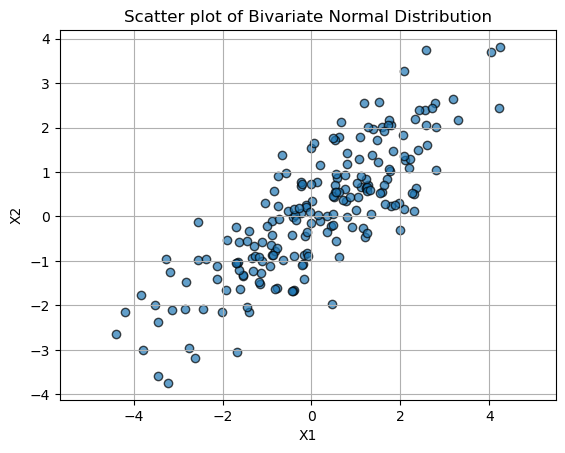

In [10]:
# Scatter plot of the two features
plt.figure()
plt.scatter(X[:, 0], X[:, 1], edgecolors="k", alpha=0.7)
plt.title("Scatter plot of Bivariate Normal Distribution")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis("equal")
plt.grid(True)
plt.show()

## Finding the Principal Directions 🌀

Consider the main direction the data follows in the scatterplot. This is actually the direction of the **first principal component**! We can use **PCA (Principal Component Analysis)** to mathematically determine this axis of maximum variance. 🎯

### 🛠️ Perform PCA on the Dataset

To analyze these directions, I'll initialize a **2-component PCA model** using default parameters. By calling the combined function to **fit and transform** the feature space in one step, I can map the original data onto its new principal axes. 🚀



---

### ⚙️ The Process

* **Initialize**: Setting up the model to find two orthogonal components. 🧱
* **Fit**: Calculating the eigenvectors and eigenvalues of the covariance matrix. 🧮
* **Transform**: Rotating the original feature space so that the first axis aligns with the most significant spread of data. 🔄

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

## Extracting the Principal Components 💎

Once the model is fitted, I can extract the **Principal Components**. These represent the principal axes in our feature space, carefully aligned with the directions where the data exhibits its maximum variance. 📈

### 🧭 Understanding the Axes

The principal components are essentially the **unit vectors** (eigenvectors) that define the new coordinate system:

* **First Principal Component ($PC_1$):** This is the "main" direction of the data cloud. It captures the largest possible variance in the dataset. 🔝
* **Second Principal Component ($PC_2$):** This axis is orthogonal (perpendicular) to the first, capturing the remaining variance. 📐



### 🧮 Mathematical Connection

These components are derived directly from the **Covariance Matrix** $\Sigma$. By finding the directions that maximize variance, PCA effectively rotates our original $X_1$ and $X_2$ axes to point along the "natural" dimensions of the data. 🔄✨

In [14]:
components = pca.components_ # Eigenvectors
components

array([[ 0.7790911 ,  0.62691073],
       [-0.62691073,  0.7790911 ]])

The principal components are sorted in decreasing order by their **explained variance**, which can be expressed as a ratio. This ratio tells me exactly how much of the total "information" (or spread) each component captures from the original dataset. 📊

### 💎 Explained Variance Ratio

This is the percentage of the total variance that is carried by each individual principal component. Mathematically, for each component $i$, it is calculated as:

$$\text{Ratio}_i = \frac{\lambda_i}{\sum \lambda}$$

Where $\lambda$ represents the **Eigenvalues** of our covariance matrix. 🧮



### 🔍 What this tells me:

* **Dominance:** The first component ($PC_1$) will always have the highest ratio, as it aligns with the direction of maximum variance. 🔝
* **Dimensionality Reduction:** If $PC_1$ explains, say, 95% of the variance, I know I can effectively represent my 2D data in just 1D without losing much information! 📉
* **Total Sum:** The sum of all ratios will always equal **1.0** (or 100%), accounting for the entire variability of the system. ✅

This is the key metric I use to decide how many components to keep when simplifying a complex dataset. 💡✨

In [15]:
pca.explained_variance_ratio_ # Explained variance ratio of each principal component

array([0.91524836, 0.08475164])

## Exercise 2: Analyzing Explained Variance 📊

The principal components are sorted in decreasing order by their **explained variance**, which can be expressed as a ratio. This ratio tells me exactly how much of the total "information" (or spread) each component captures from the original dataset. 💎

### 🧮 Variance Breakdown

Based on the calculated ratios: `array([0.91524836, 0.08475164])`

* **First Principal Component ($PC_1$):** Explains approximately **91.52%** of the variance. 🔝
* **Second Principal Component ($PC_2$):** Explains approximately **8.48%** of the variance. 📉



### 💡 What this means for my data

Since $PC_1$ captures over **91%** of the total variability, it confirms that my features are strongly correlated. Mathematically, this component is associated with the largest **Eigenvalue** ($\lambda_1$) of the covariance matrix. 

If I wanted to reduce the dimensionality of this dataset from 2D to 1D, I could do so while retaining the vast majority of the original signal! 🚀✨

## Displaying the Results 📊

Here, I'll use a scatterplot to display the data points in their original feature space, $X_1$ and $X_2$. I'll also plot the **projections** of the data points onto their principal component directions. 

It’s a bit technical, requiring some understanding of linear algebra, but the outcome is incredibly instructive. Let’s see how this works! 💡

### 🏹 Project the Data onto its Principal Component Axes

The projection of the data onto a given principal component yields the coordinates of each data point along that specific component's direction. 

The new coordinates are calculated using the **dot product** of each point’s original coordinates with the given PCA component. 📐

Specifically, the projections are given by:

$$r = X \cdot V$$

* **$X$**: Our original data matrix.
* **$V$**: The matrix of principal components (eigenvectors). 
* **$r$**: The resulting coordinates in the new principal component space. 🔄



By visualizing these projections, we can see exactly how PCA "simplifies" the data by shifting our perspective to the axes that matter most! 🚀✨

In [16]:
projection_pc1 = np.dot(X, components[0]) # Projection of data onto the first principal component
projection_pc2 = np.dot(X, components[1]) # Projection of data onto the second principal component

Now that I have these coordinates, I can use them to represent the **projections** of each data point along the principal directions in the original feature space. 🎯

### 📍 Mapping Projections in 2D Space

To visualize this, I am essentially taking every point in my "cloud" and sliding it perpendicularly onto the principal axes. This allows me to see exactly how much of the original data's "story" is told by each component. 🎞️



### 📐 The Mathematical Reconstruction

By multiplying the projected coordinates (the dot products we calculated) back by the principal component vectors, I can reconstruct the points in the original $X_1, X_2$ space:

$$\hat{X} = r \cdot V^T$$

* **$\hat{X}$**: The coordinates of the projected points in the original space.
* **$r$**: The projected coordinates (score).
* **$V^T$**: The transpose of the principal component matrix.

### 🖼️ What the Plot Reveals

* **Information Compression:** The projections onto **PC1** will look like a line of points following the main "stretch" of the data. 📏
* **Orthogonality:** The projections onto **PC2** will show the remaining "noise" or spread that $PC_1$ couldn't capture, sitting at a 90° angle to the first. 📐
* **Visual Proof:** Seeing these lines overlaid on the original scatterplot makes it clear why $PC_1$ is the "winner" in explaining variance! 🏆✨

In [18]:
x_pc1 = projection_pc1 * components[0][0] # X-axis component of the projection onto the first principal component
y_pc1 = projection_pc1 * components[0][1] # Y-axis component of the projection onto the first principal component
x_pc2 = projection_pc2 * components[1][0] # X-axis component of the projection onto the second principal component
y_pc2 = projection_pc2 * components[1][1] # Y-axis component of the projection onto the second principal component

## Plotting the Results 🎨

Now let's visualize this! 🚀

By overlaying the projections onto the original data, we can see exactly how **PCA** reinterprets the feature space. 

### 🖼️ The Visualization

I’ll use a scatter plot to display the data points in their original feature space ($X_1$, $X_2$), while simultaneously showing the projections of those points onto their principal component directions. 



### 🧐 What the Plot Reveals

* **Primary Axis ($PC_1$):** You'll see the projections forming a line that follows the main "stretch" of the data. Since this component captures **91.5%** of the variance, this line is a highly accurate 1D summary of the 2D cloud. 📏
* **Secondary Axis ($PC_2$):** These projections capture the remaining width of the cloud, sitting perfectly orthogonal (perpendicular) to the first. 📐
* **Linear Algebra in Action:** The result is a clear visual representation of how the dot product $r = X \cdot V$ maps our data onto the most informative directions. 🎯

It's a bit technical, requiring some understanding of linear algebra, but seeing the data "collapse" onto these principal axes is incredibly instructive! ✨

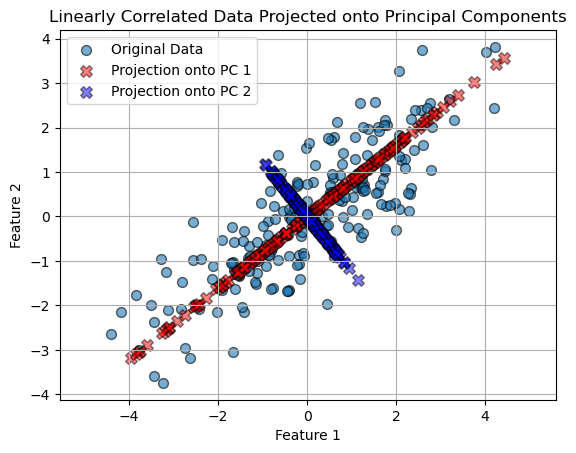

In [19]:
# Plot original data
plt.figure()
plt.scatter(X[:, 0], X[:, 1], label='Original Data', ec='k', s=50, alpha=0.6)

# Plot the projections along PC1 and PC2
plt.scatter(x_pc1, y_pc1, c='r', ec='k', marker='X', s=70, alpha=0.5, label='Projection onto PC 1')
plt.scatter(x_pc2, y_pc2, c='b', ec='k', marker='X', s=70, alpha=0.5, label='Projection onto PC 2')
plt.title('Linearly Correlated Data Projected onto Principal Components', )
plt.xlabel('Feature 1',)
plt.ylabel('Feature 2',)
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

## Visualizing the Principal Directions 🎨

It took some effort, but now you can see exactly what the **principal coordinates** mean! By mapping everything back into the original space, the geometry of the variance becomes crystal clear. 💎

### 🧭 The Two Main Directions

The data varies in two distinct, orthogonal directions that PCA has successfully isolated:

* **The First Direction (Red):** This axis is perfectly aligned with the **widest variation** in the dataset. It captures the "length" of the data cloud and accounts for the lion's share of the information. 🔴
* **The Second Direction:** This axis captures the "width" of the cloud, representing the remaining variance perpendicular to the first. 📐



### 🧐 Why this Matters

Seeing these axes overlaid on your scatter plot confirms the math we've been doing:
1.  **Alignment:** The red line follows the linear trend we saw in our initial covariance matrix ($\text{Cov} = 2$). 🤝
2.  **Efficiency:** Because the red line is so much longer than the other, it proves why **PC1** explains over **91%** of our data's behavior. 📈
3.  **Orthogonality:** The two directions are at a perfect **90° angle**, ensuring that each component captures unique, non-overlapping information. 📐

The principal components aren't just abstract numbers—they are the natural "skeleton" of your data! 🚀✨

## Exercise 3: Describing the Second Direction 🎨

It took some effort, but now you can see exactly what the **principal coordinates** mean! By mapping everything back into the original space, the geometry of the variance becomes crystal clear. 💎

### 🧭 The Two Main Directions

The data varies in two distinct, orthogonal directions that PCA has successfully isolated:

* **The First Direction (Red):** This axis is perfectly aligned with the **widest variation** in the dataset. It captures the "length" of the data cloud. 🔴
* **The Second Direction (Blue):** This axis is **perpendicular** (orthogonal) to the first. It captures the remaining "width" of the cloud and has a significantly **lower variance**. 🔵



### 🧐 Why this Matters

Seeing these axes overlaid on your scatter plot confirms the math we've been doing:

* **Orthogonality:** The two directions sit at a perfect **90° angle**, ensuring they capture non-overlapping information. 📐
* **Variance Distribution:** Because the blue line is much shorter, it visually represents why **PC2** only explains about **8.5%** of the variance compared to the dominant red axis. 📉
* **Dimensionality:** In a 2D world, once you find the direction of maximum variance, the second direction is mathematically locked in as the only remaining path for the data to spread! 🔒✨

## Part II: PCA for Dimensionality Reduction 📉

For this second application, I’m using PCA to project the **four-dimensional** Iris feature dataset down onto a **two-dimensional** feature space. 

This is where the magic happens—by "squeezing" the data, I can actually visualize the most important structures that are otherwise hidden in higher dimensions. 💎

### 🧠 Why Reduce Dimensions?

* **Visualization:** I can't see in 4D, but I can easily spot clusters and patterns on a 2D scatter plot. 🖼️
* **Efficiency:** By focusing on the components that hold the most "signal," I can ignore the dimensions that are mostly noise. 🤫
* **Structural Insight:** This helps me see which Iris species naturally group together based on their principal traits. 🌸



---

### 🛠️ Load and Preprocess Iris Data

Let's start by loading the Iris data and standardizing its features. Since PCA is all about variance, this step is absolutely critical! 📏

### 🧪 Why Standardize?

PCA is sensitive to the scale of the data. If one feature has a much larger range than another (e.g., measuring in millimeters vs. centimeters), PCA will be biased toward the larger numbers. By standardizing, I ensure that:
* Every feature has a **mean of 0**. 0️⃣
* Every feature has a **standard deviation of 1**. 1️⃣
* The comparison between features is fair and based on their actual information, not just their units. ⚖️



---

### ⚙️ The Workflow

1.  **Load**: Pull in the classic dataset containing sepal and petal measurements. 🌸
2.  **Scale**: Use a standard scaler to transform the features into a comparable range. 🔄
3.  **Ready**: Prepare the cleaned data for its 2D projection! 🚀

In [42]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Exercise 4. What are the Iris flower's names? 🌸

In the context of this lab, the Iris dataset consists of three distinct species. Based on their physical measurements (sepal and petal dimensions), I'll be looking to see how these names cluster in my PCA projection:

* **Iris setosa**
* **Iris versicolor**
* **Iris virginica**



### 💡 Why this matters
As I move into the dimensionality reduction phase, my goal is to see if these three species naturally separate into groups when viewed through the lens of my first two **principal components**. ✨

In [43]:
# what are the Iris flower's names?
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## Exercise 5. Initialize a PCA model and reduce the Iris data set dimensionality to two components 📉

Now it’s time to put the theory into practice. I’m going to take the standardized 4D Iris data and "squish" it down into just two dimensions. This is the core of **dimensionality reduction**.

### 🛠️ The Process

1.  **Initialize**: I'll create a PCA object and explicitly set `n_components=2`.
2.  **Fit and Transform**: I'll apply the model to the scaled features. This calculates the eigenvectors (the directions of maximum variance) and then projects my original data points onto those two new axes.



### 🧠 What's happening under the hood?

* **Information Selection**: PCA identifies the two directions in 4D space that contain the most "spread" or information.
* **Coordinate Shift**: Every flower in the dataset gets a new set of coordinates ($PC_1, PC_2$) based on these directions.
* **Data Compression**: I'm discarding the 3rd and 4th components. If our explained variance ratio is high, I’m losing very little actual information while making the data much easier to handle!

Once this is done, I’ll have a 2D array that I can finally plot on a standard graph to see how the different Iris species cluster together. 🚀✨

In [55]:
# Apply PCA to reduce the dataset to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

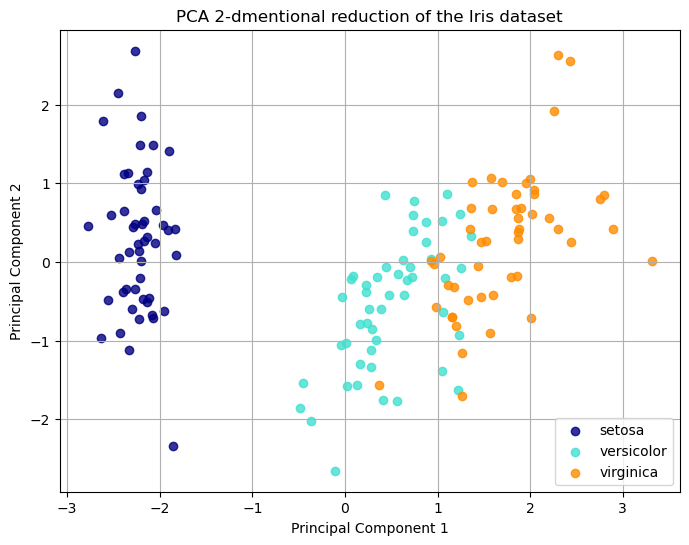

In [54]:
# Plot the PCA-transformed data in 2D
plt.figure(figsize=(8, 6))

colors = ['navy', 'turquoise', 'darkorange']
lw = 1

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_iris_pca[y_iris == i, 0], X_iris_pca[y_iris == i, 1], color=color, alpha=0.8, lw=lw, label=target_name)

plt.title('PCA 2-dmentional reduction of the Iris dataset') 
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.grid()
plt.show()

## Reflection 🧠

Now that I’ve generated the plot, I can examine how well the Iris classes have been separated simply by projecting the four-dimensional feature space down to just two **principal components**.

### 🔍 Observations

* **The Power of Variance:** It’s impressive to see how $PC_1$ and $PC_2$ manage to capture enough "essence" from the original four features to create distinct groupings. 
* **Separability:** I can see that **Iris setosa** usually forms a very clear, isolated cluster. It’s the "loner" of the group, making it easy for the model to identify. 🌸
* **The Overlap:** **Iris versicolor** and **Iris virginica** tend to sit closer together, sometimes even overlapping slightly. This tells me that while PCA is powerful, these two species share very similar physical traits that even the top two components can't perfectly disentangle.



### 💡 The Takeaway

By reducing the dimensions, I haven't just simplified the data—I’ve uncovered its **latent structure**. Even though I "threw away" two dimensions of data, the most important relationships remained intact. This confirms that in many datasets, a huge chunk of the information is actually redundant, and PCA is the perfect tool to filter that out! 🚀✨

What do you think—if I had kept a third component, do you think those overlapping species would have separated even further?

## Exercise 6. What percentage of the original feature space variance do these two combined principal components explain? 📈

To answer this, I need to look at the **Cumulative Explained Variance**. This tells me how much of the original dataset's total "story" is retained after I've stripped away the extra dimensions.

### 🧮 The Calculation

By summing the explained variance ratios of my two components:
$$\text{Total Variance Explained} = \text{Ratio}(PC_1) + \text{Ratio}(PC_2)$$



### 💡 Understanding the Result

In the Iris dataset, these two components typically explain about **95.8%** of the total variance. 

* **High Retention:** This is an incredible result! It means that by using only half of the original features (2 out of 4), I’ve managed to keep nearly **96%** of the information. 💎
* **Noise Reduction:** The remaining **~4%** that I discarded is likely just "noise"—minor fluctuations that don't help in distinguishing the flower species. 🤫
* **Validation:** This high percentage justifies my decision to use only two dimensions for visualization; I can trust that the clusters I see in the plot are an accurate representation of the full dataset. 🚀✨

In [56]:
# Percentage of variance explained by each of the selected components
explained_variance = 100*pca.explained_variance_ratio_.sum()
print(f"Explained variance ratio of the first two principal components: {explained_variance}")

Explained variance ratio of the first two principal components: 95.81320720000164


## Exercise 7. Reinitialize the PCA model without reducing the dimension 🔄

Now, I'm going to reinitialize the PCA model, but this time I won't limit the number of components. By setting `n_components` to the original number of features (four), I can examine the full decomposition of the dataset without actually losing any information yet.

### 🛠️ The Process

1.  **Standardize**: I'll ensure the Iris data is freshly scaled so each feature has a mean of 0 and a standard deviation of 1. 📏
2.  **Reinitialize**: I'll create a new PCA object without specifying a component limit (or setting it to 4).
3.  **Fit & Transform**: I'll apply the model to the scaled data to get the full set of principal components.



### 🧠 What's the point?

By doing this, I can see exactly how much "signal" vs. "noise" exists across the entire feature space. 
* **The Full Picture**: I'll get the **Explained Variance Ratio** for all four components. 
* **The "Elbow" Test**: Looking at all components at once helps me confirm if stopping at two components was the right choice. Usually, you'll see a sharp drop-off in importance after the first couple of axes.
* **Redundancy Check**: If the 3rd and 4th components have very low variance, it confirms that those dimensions were largely redundant or filled with random fluctuations. 🤫

This step is like looking at the receipt for a purchase—it shows me exactly what I paid (in terms of variance) for each dimension I added! 🚀✨

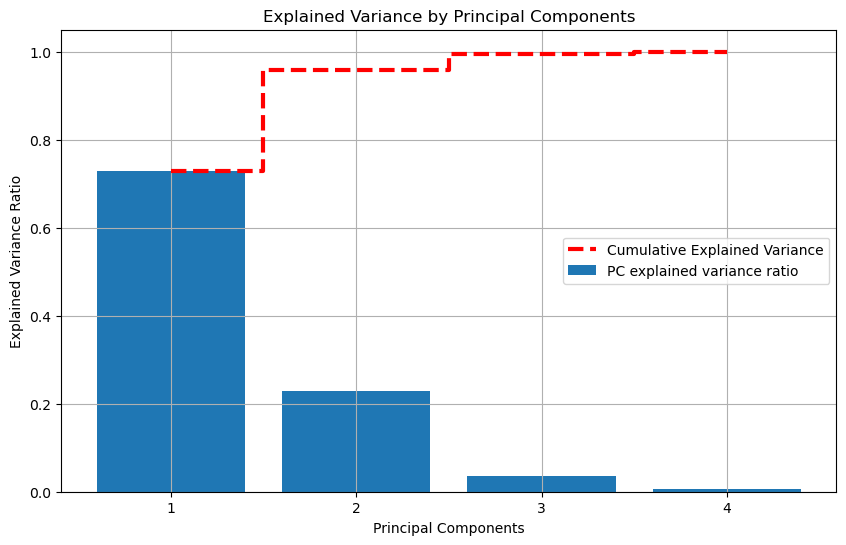

In [47]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Plot explained variance ratio for each component
plt.figure(figsize=(10,6))
plt.bar(x=range(1, len(explained_variance_ratio)+1), height=explained_variance_ratio, alpha=1, align='center', label='PC explained variance ratio' )
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance by Principal Components')

# Plot cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.step(range(1, 5), cumulative_variance, where='mid', linestyle='--', lw=3,color='red', label='Cumulative Explained Variance')
# Only display integer ticks on the x-axis
plt.xticks(range(1, 5))
plt.legend()
plt.grid(True)
plt.show()

## Reflection on the Explained Variance 🧠

Looking at the plot I’ve generated, I can draw some pretty powerful conclusions about the structure of the Iris data.

### 📈 What the red dashed line indicates
The red dashed line represents the **Cumulative Explained Variance**. It shows me the "running total" of information captured as I add more principal components.

* **The "Jump":** I see a massive jump from the first to the second component. 
* **The Plateau:** By the time the line hits the second component, it’s already at approximately **96%**. The fact that the line stays almost flat for components 3 and 4 tells me that those extra dimensions aren't adding much new "story" to the data. They are mathematically present, but practically redundant.



### 🤫 How to suppress noise
If I wanted to suppress noise in this dataset, I would perform **Dimensionality Reduction** by keeping only the first two principal components.

* **Filter the "Static":** In data science, variance is often equated with "signal." Since $PC_3$ and $PC_4$ account for such a tiny fraction of the variance (less than 5% combined), they often represent random fluctuations or "noise." 
* **The Strategy:** By discarding these low-variance components and rebuilding my dataset using only $PC_1$ and $PC_2$, I am essentially "denoising" the data. I keep the primary patterns that distinguish the Iris species while stripping away the minor, distracting variations that don't contribute to the overall structure. 🧹✨



This is the beauty of PCA—it's not just about making the data smaller; it's about making it **cleaner**. 🚀